In [1]:
import sys
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du
from Pipeline1_SNR_datasets import execute_specsnr_algorithm

plt.style.use("/home/2649/repos/foxstyle/custom.mplstyle")

In [2]:
df = pd.read_parquet("/home/2649/repos/spec_res/data/forSNR/dataset.parquet")
wvl, spectra, df_meta = du.unpack_dataset(df)
subtypes = df_meta["SN Subtype"].unique()

In [3]:
features = [
    ["Ia-norm", 0, np.inf, None, "$t_p \leq 20$"],  # SiII 6355
    ["Ia-norm", 25, np.inf, None, "$t_p > 20$"],         # Triplet 5855
    ["Ia-91T", 0, np.inf, None, "$t_p \leq 20$"],   # SiII 6355
    ["Ia-91T", 25, np.inf, None, "$20 < t_p$"],          # Triplet 5855
    ["Ia-91bg", 0, np.inf, None, "$t_p \leq 20$"],  # SiII 6355
    ["Ia-91bg", 25, np.inf, None, "$t_p > 20$"],         # Triplet 5855
    ["Iax", 0, np.inf, None, "$t_p \leq 7$"],      # FeIII 5129
    ["Iax", 14, np.inf, None, "$7 < t_p$"],     # FeII 5169
    ["Ib-norm", 0, np.inf, None, "All $t_p$"],  # HeI 5876
    ["Ibn", 0, np.inf, None, "All phases"],      # HeI 5876 (Emission)
    ["IIb", -5, np.inf, None, "$t_p \leq 0$"],     # Ha 6562
    ["IIb", 5, np.inf, None, "$0 < t_p$"],      # HeI 5876
    ["Ic-norm", 0, np.inf, None, "All $t_p$"],  # NaI D 5895
    ["Ic-broad", 0, np.inf, None, "All $t_p$"], # NaI D 5895
    ["IIP", 0, np.inf, None, "All $t_p$"],      # Ha 6562
]

for i in range(df.shape[0]):
    subtype = df_meta.loc[i, "SN Subtype"]
    phase = df_meta.loc[i, "Spectrum Phase"]

    for feature in features:
        if feature[0] != subtype:
            continue
        
        closeness = np.abs(feature[1] - phase)
        if closeness < feature[2]:
            feature[3] = i
            feature[2] = closeness

features

[['Ia-norm', 0, 0.0, 61, '$t_p \\leq 20$'],
 ['Ia-norm', 25, 0.0, 214, '$t_p > 20$'],
 ['Ia-91T', 0, 0.0, 2197, '$t_p \\leq 20$'],
 ['Ia-91T', 25, 0.10000000000000142, 2122, '$20 < t_p$'],
 ['Ia-91bg', 0, 0.2, 2380, '$t_p \\leq 20$'],
 ['Ia-91bg', 25, 0.0, 2406, '$t_p > 20$'],
 ['Iax', 0, 0.0, 2646, '$t_p \\leq 7$'],
 ['Iax', 14, 0.1999999999999993, 2601, '$7 < t_p$'],
 ['Ib-norm', 0, 0.0, 2817, 'All $t_p$'],
 ['Ibn', 0, 5.5, 2861, 'All phases'],
 ['IIb', -5, 0.0, 2882, '$t_p \\leq 0$'],
 ['IIb', 5, 0.09999999999999964, 2931, '$0 < t_p$'],
 ['Ic-norm', 0, 0.1, 3113, 'All $t_p$'],
 ['Ic-broad', 0, 0.0, 3384, 'All $t_p$'],
 ['IIP', 0, 0.1, 3532, 'All $t_p$']]

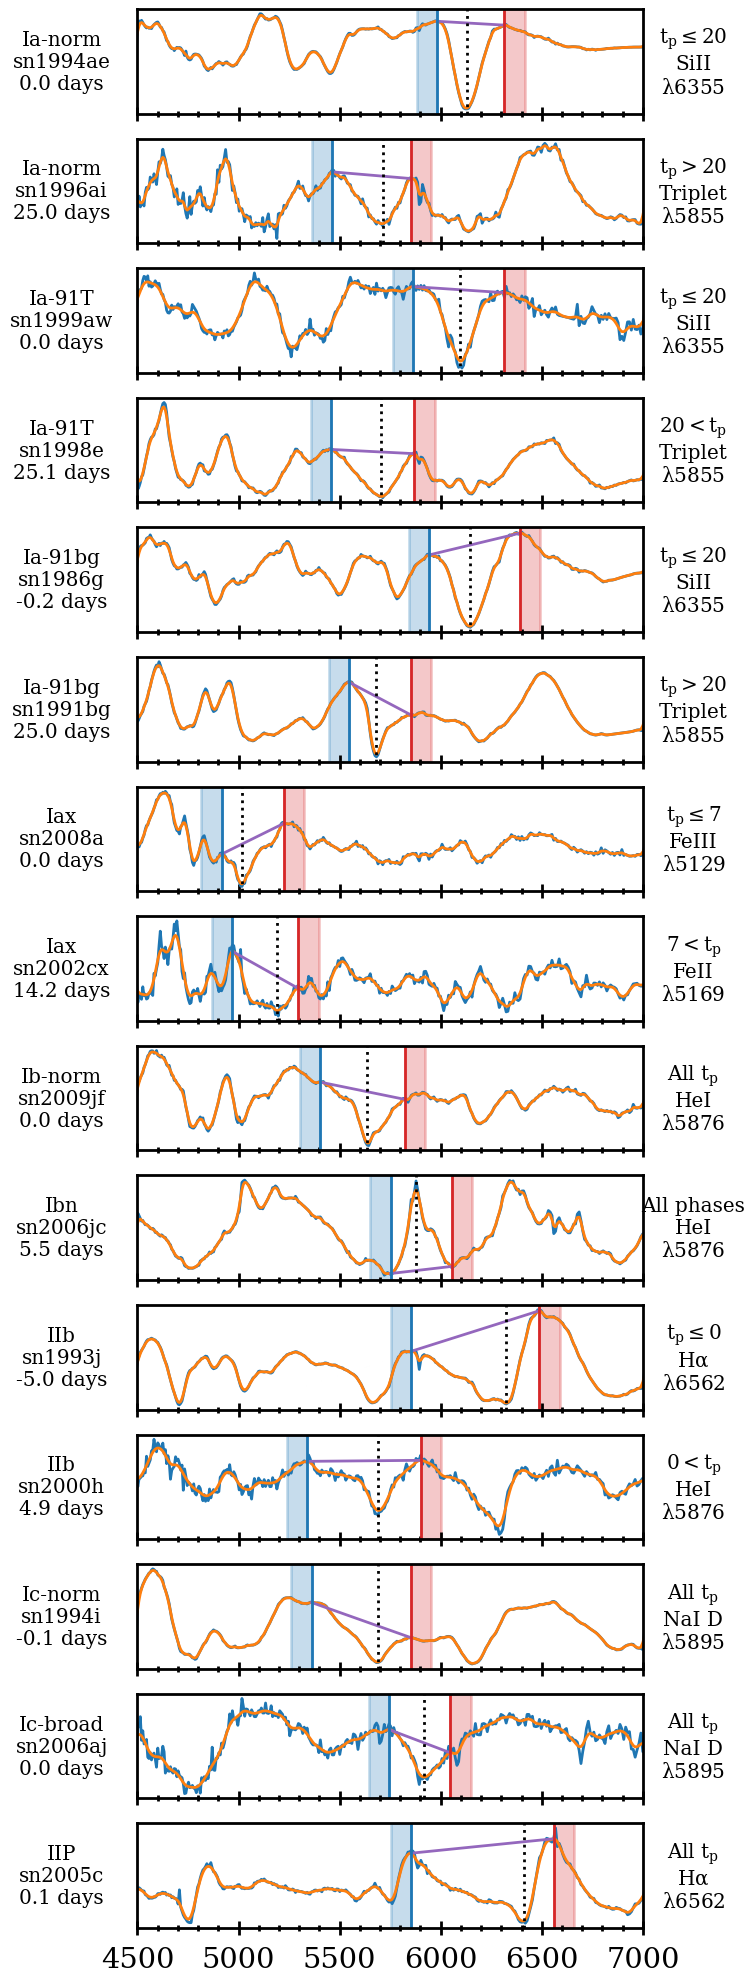

In [4]:
fig, axes = plt.subplots(nrows=len(features), ncols=1, sharex=True, figsize=(8, 20))

for j, feature_set in enumerate(features):
    i = feature_set[3]
    specsnr = ms.SpectrumSNR(
        df_meta.loc[i, "SN Name"],
        df_meta.loc[i, "SN Subtype"],
        df_meta.loc[i, "Spectrum Phase"],
        wvl,
        spectra[i])
    
    execute_specsnr_algorithm(
        specsnr,
        df_meta.loc[i, "Denoising Parameter"],
        df_meta.loc[i, "minima_i"],
        df_meta.loc[i, "searchBlu"],
        df_meta.loc[i, "searchRed"],
        df_meta.loc[i, "maxBlu"],
        df_meta.loc[i, "maxRed"],
        df_meta.loc[i, "noiseWindowBlu"],
        df_meta.loc[i, "noiseWindowRed"],
        df_meta.loc[i, "useBlu"],
        df_meta.loc[i, "useRed"],
        normalize=True)

    axes[j].plot(wvl, spectra[i], c="tab:blue")
    axes[j].plot(wvl, specsnr.signal, c="tab:orange")
    axes[j].plot(specsnr.pc_wvl, specsnr.pseudo_cont, c="tab:purple")
    
    axes[j].axvline(specsnr.line_observed, c="k", ls=":")
    axes[j].axvline(x=specsnr.wvl_shoulder_red, c="tab:red")
    axes[j].axvline(x=specsnr.wvl_shoulder_blu, c="tab:blue")
    axes[j].axvspan(
        specsnr.blu_range[0], specsnr.blu_range[1],
        color="tab:blue",
        alpha=0.25)
    axes[j].axvspan(
        specsnr.red_range[0], specsnr.red_range[1],
        color="tab:red",
        alpha=0.25)
    
    
    axes[j].tick_params(
        axis="both",
        which="both",
        direction="inout",
        bottom=True, top=False, left=False, right=False)
    axes[j].set_yticklabels([])
    
    name = df_meta.loc[i, 'SN Name']
    if name[0] == "u":
        name = name[1:]
    subtype_confirm = df_meta.loc[i, 'SN Subtype']
    phase = df_meta.loc[i, 'Spectrum Phase']
    SNR = df_meta.loc[i, "SNR"]
    
    axes[j].text(
        -0.15,
        0.5,
        f"{subtype_confirm}\n{name}\n{phase} days",
        ha="center", va="center",
        size="large",
        transform=axes[j].transAxes)

    axes[j].text(
        1.1,
        0.5,
        f"{feature_set[4]}\n{specsnr.line_name}\n$\lambda${specsnr.line}",
        ha="center", va="center",
        size="large",
        transform=axes[j].transAxes)

axes[0].set_xlim((4500, 7000))
fig.tight_layout()
fig.savefig("each_spectral_feature.pdf")
fig.savefig("each_spectral_feature.png")
fig.show()